In [2]:
# Install required packages
%pip install tensorflow numpy matplotlib seaborn scikit-learn pandas

Defaulting to user installation because normal site-packages is not writeable
  Using cached tensorflow-2.21.0-cp311-cp311-win_amd64.whl.metadata (4.5 kB)
Using cached tensorflow-2.21.0-cp311-cp311-win_amd64.whl (350.8 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Inception Network (GoogleNet) Model with TensorFlow/Keras

This notebook implements the Inception (GoogleNet) convolutional neural network architecture using TensorFlow/Keras for image classification on the CIFAR-10 dataset.

## Objectives:
- Load and preprocess the CIFAR-10 dataset
- Build the Inception Network model architecture
- Train with different optimizers (SGD, Adam, RMSProp)
- Apply regularization techniques (Dropout, L1/L2, EarlyStopping)
- Perform basic hyperparameter tuning
- Visualize training curves and confusion matrix
- Evaluate model performance
- Save the trained model

In [3]:
# Import Required Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import pandas as pd
import os
from collections import Counter

In [4]:
# Dataset Loading Function
def load_cifar10_dataset():
    """
    Load CIFAR-10 dataset from TensorFlow/Keras
    """
    print("Loading CIFAR-10 dataset from TensorFlow/Keras...")
    # Load CIFAR-10 dataset
    (train_images, train_labels), (test_images, test_labels) = keras.datasets.cifar10.load_data()
    return (train_images, train_labels), (test_images, test_labels)

# Load the dataset
(train_images, train_labels), (test_images, test_labels) = load_cifar10_dataset()
print("Dataset loaded successfully!")

Loading CIFAR-10 dataset from TensorFlow/Keras...
A local file was found, but it seems to be incomplete or outdated because the auto file hash does not match the original value of 6d958be074577803d12ecdefd02955f39262c83c16fe9348329d7fe0b5c001ce so we will re-download the data.
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 64s 0us/step
Dataset loaded successfully!


Dataset Info:
Train images shape: (50000, 32, 32, 3)
Train labels shape: (50000, 1)
Test images shape: (10000, 32, 32, 3)
Test labels shape: (10000, 1)

Image data type: uint8
Label data type: uint8

Sample Data:


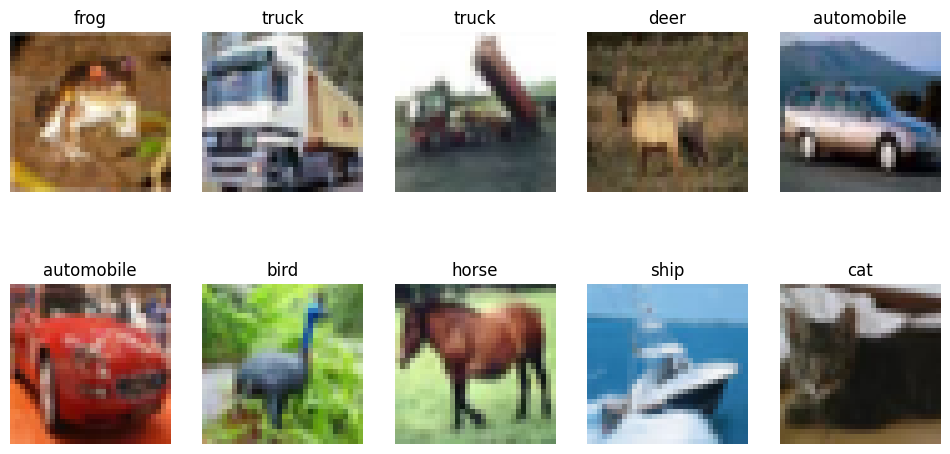


Label Distribution:
Train set:
  airplane: 5000
  automobile: 5000
  bird: 5000
  cat: 5000
  deer: 5000
  dog: 5000
  frog: 5000
  horse: 5000
  ship: 5000
  truck: 5000
Test set:
  airplane: 1000
  automobile: 1000
  bird: 1000
  cat: 1000
  deer: 1000
  dog: 1000
  frog: 1000
  horse: 1000
  ship: 1000
  truck: 1000


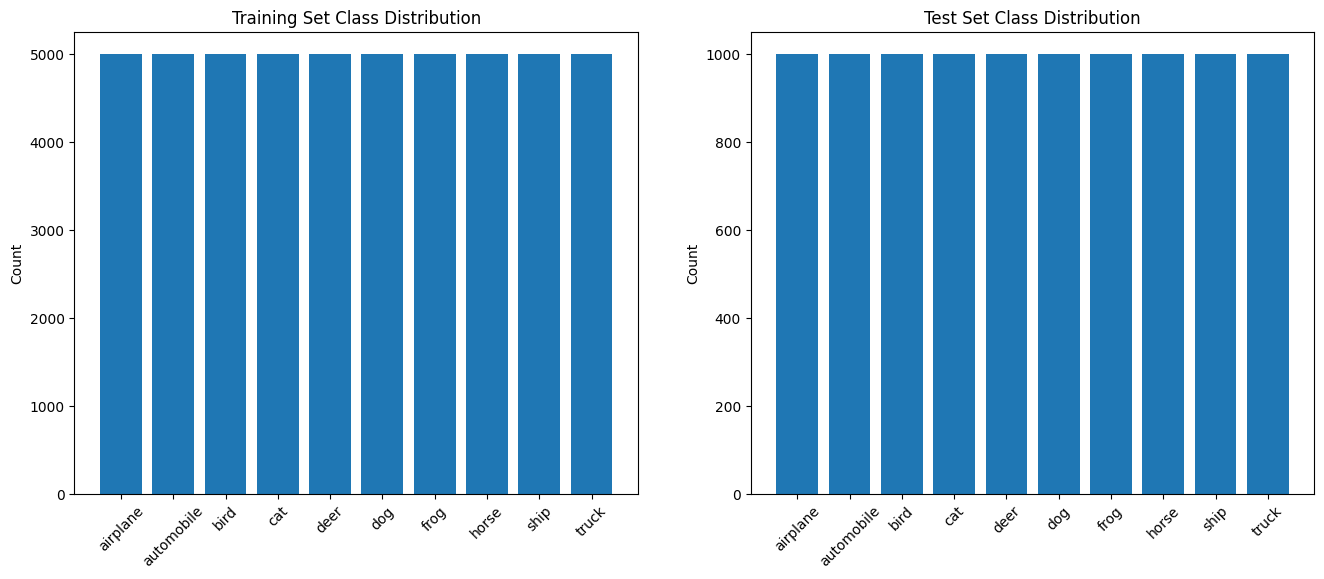

In [5]:
# Dataset Exploration
def explore_cifar10_dataset(train_images, train_labels, test_images, test_labels):
    """
    Display dataset shape, sample data, and label distribution
    """
    class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
    
    print("Dataset Info:")
    print(f"Train images shape: {train_images.shape}")
    print(f"Train labels shape: {train_labels.shape}")
    print(f"Test images shape: {test_images.shape}")
    print(f"Test labels shape: {test_labels.shape}")
    
    print(f"\nImage data type: {train_images.dtype}")
    print(f"Label data type: {train_labels.dtype}")
    
    # Sample data
    print("\nSample Data:")
    plt.figure(figsize=(12, 6))
    for i in range(10):
        plt.subplot(2, 5, i+1)
        plt.imshow(train_images[i])
        plt.title(f"{class_names[train_labels[i][0]]}")
        plt.axis('off')
    plt.show()
    
    # Label distribution
    train_label_counts = Counter(train_labels.flatten())
    test_label_counts = Counter(test_labels.flatten())
    
    print("\nLabel Distribution:")
    print("Train set:")
    for label in sorted(train_label_counts.keys()):
        print(f"  {class_names[label]}: {train_label_counts[label]}")
    
    print("Test set:")
    for label in sorted(test_label_counts.keys()):
        print(f"  {class_names[label]}: {test_label_counts[label]}")
    
    # Plot distribution
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    train_counts = [train_label_counts[i] for i in range(10)]
    test_counts = [test_label_counts[i] for i in range(10)]
    
    ax1.bar(class_names, train_counts)
    ax1.set_title('Training Set Class Distribution')
    ax1.set_ylabel('Count')
    ax1.tick_params(axis='x', rotation=45)
    
    ax2.bar(class_names, test_counts)
    ax2.set_title('Test Set Class Distribution')
    ax2.set_ylabel('Count')
    ax2.tick_params(axis='x', rotation=45)
    
    plt.show()

# Explore the dataset
explore_cifar10_dataset(train_images, train_labels, test_images, test_labels)

In [6]:
# Preprocessing
def preprocess_cifar10_data(train_images, train_labels, test_images, test_labels):
    """
    Preprocess CIFAR-10 data: normalize, convert labels to categorical, split validation
    """
    # Normalize pixel values to [0, 1]
    train_images = train_images.astype('float32') / 255.0
    test_images = test_images.astype('float32') / 255.0
    
    # Convert labels to categorical
    train_labels = keras.utils.to_categorical(train_labels, 10)
    test_labels = keras.utils.to_categorical(test_labels, 10)
    
    # Split train into train and validation
    val_split = 0.1
    val_size = int(len(train_images) * val_split)
    
    val_images = train_images[:val_size]
    val_labels = train_labels[:val_size]
    train_images = train_images[val_size:]
    train_labels = train_labels[val_size:]
    
    return (train_images, train_labels), (val_images, val_labels), (test_images, test_labels)

# Preprocess data
(train_X, train_y), (val_X, val_y), (test_X, test_y) = preprocess_cifar10_data(
    train_images, train_labels, test_images, test_labels
)

print(f"Training data shape: {train_X.shape}")
print(f"Validation data shape: {val_X.shape}")
print(f"Test data shape: {test_X.shape}")
print(f"Number of classes: {train_y.shape[1]}")

Training data shape: (45000, 32, 32, 3)
Validation data shape: (5000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)
Number of classes: 10


In [7]:
# Build Inception Module
def inception_module(x, filters):
    """
    Inception module with multiple filter sizes
    """
    # 1x1 conv
    conv1x1 = layers.Conv2D(filters[0], (1, 1), padding='same', activation='relu',
                           kernel_regularizer=keras.regularizers.l2(0.01))(x)
    
    # 3x3 conv
    conv3x3 = layers.Conv2D(filters[1], (1, 1), padding='same', activation='relu',
                           kernel_regularizer=keras.regularizers.l2(0.01))(x)
    conv3x3 = layers.Conv2D(filters[2], (3, 3), padding='same', activation='relu',
                           kernel_regularizer=keras.regularizers.l2(0.01))(conv3x3)
    
    # 5x5 conv
    conv5x5 = layers.Conv2D(filters[3], (1, 1), padding='same', activation='relu',
                           kernel_regularizer=keras.regularizers.l2(0.01))(x)
    conv5x5 = layers.Conv2D(filters[4], (5, 5), padding='same', activation='relu',
                           kernel_regularizer=keras.regularizers.l2(0.01))(conv5x5)
    
    # Max pooling
    pool = layers.MaxPooling2D((3, 3), strides=(1, 1), padding='same')(x)
    pool = layers.Conv2D(filters[5], (1, 1), padding='same', activation='relu',
                        kernel_regularizer=keras.regularizers.l2(0.01))(pool)
    
    # Concatenate
    output = layers.concatenate([conv1x1, conv3x3, conv5x5, pool], axis=-1)
    return output

# Build Inception Network
def build_inception_model(num_classes=10):
    """
    Build Inception Network (simplified GoogleNet) with regularization
    """
    inputs = keras.Input(shape=(32, 32, 3))
    
    # Initial conv layer
    x = layers.Conv2D(64, (7, 7), strides=(2, 2), padding='same', activation='relu',
                     kernel_regularizer=keras.regularizers.l2(0.01))(inputs)
    x = layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)
    x = layers.BatchNormalization()(x)
    
    # Inception modules
    x = inception_module(x, [64, 96, 128, 16, 32, 32])  # Inception 3a
    x = inception_module(x, [128, 128, 192, 32, 96, 64])  # Inception 3b
    x = layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)
    
    x = inception_module(x, [192, 96, 208, 16, 48, 64])  # Inception 4a
    x = inception_module(x, [160, 112, 224, 24, 64, 64])  # Inception 4b
    x = inception_module(x, [128, 128, 256, 24, 64, 64])  # Inception 4c
    x = inception_module(x, [112, 144, 288, 32, 64, 64])  # Inception 4d
    x = inception_module(x, [256, 160, 320, 32, 128, 128])  # Inception 4e
    x = layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)
    
    x = inception_module(x, [256, 160, 320, 32, 128, 128])  # Inception 5a
    x = inception_module(x, [384, 192, 384, 48, 128, 128])  # Inception 5b
    
    # Global average pooling
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    
    # Dense layers
    x = layers.Dense(1024, activation='relu', kernel_regularizer=keras.regularizers.l1_l2(l1=0.01, l2=0.01))(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = keras.Model(inputs, outputs)
    return model

# Build model
model = build_inception_model()

# Print model summary
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 16, 16,    │      9,472 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 8, 8, 64)  │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 8, 8, 64)  │        256 │ max_pooling2d[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 8, 8, 96)  │      6,240 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 8, 8, 16)  │      1,040 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 8, 8, 64)  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 8, 8, 64)  │      4,160 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 8, 8, 128) │    110,720 │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 8, 8, 32)  │     12,832 │ conv2d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 8, 8, 32)  │      2,080 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 8, 8, 256) │          0 │ conv2d_1[0][0],   │
│ (Concatenate)       │                   │            │ conv2d_3[0][0],   │
│                     │                   │            │ conv2d_5[0][0],   │
│                     │                   │            │ conv2d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 8, 8, 128) │     32,896 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 8, 8, 32)  │      8,224 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 8, 8, 256) │          0 │ concatenate[0][0] │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 8, 8, 128) │     32,896 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 8, 8, 192) │    221,376 │ conv2d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 8, 8, 96)  │     76,896 │ conv2d_10[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 8, 8, 64)  │     16,448 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 8, 8, 480) │          0 │ conv2d_7[0][0],   │
│ (Concatenate)       │                   │            │ conv2d_9[0][0], 

 Total params: 6,892,090 (26.29 MB)

 Trainable params: 6,891,962 (26.29 MB)

 Non-trainable params: 128 (512.00 B)

In [ ]:
# Training with Different Optimizers
def train_with_optimizer(model, optimizer_name, train_X, train_y, val_X, val_y, epochs=10):
    """
    Train model with specified optimizer and regularization
    """
    if optimizer_name == 'SGD':
        optimizer = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
    elif optimizer_name == 'Adam':
        optimizer = keras.optimizers.Adam(learning_rate=0.001)
    elif optimizer_name == 'RMSProp':
        optimizer = keras.optimizers.RMSprop(learning_rate=0.001)
    
    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    
    # Early stopping
    early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    
    # Data augmentation
    datagen = keras.preprocessing.image.ImageDataGenerator(
        rotation_range=15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True
    )
    
    history = model.fit(datagen.flow(train_X, train_y, batch_size=32),
                       validation_data=(val_X, val_y),
                       epochs=epochs,
                       callbacks=[early_stopping],
                       verbose=1)
    
    return history

# Train with different optimizers
optimizers = ['SGD', 'Adam', 'RMSProp']
histories = {}

for opt in optimizers:
    print(f"\nTraining with {opt} optimizer...")
    model_copy = build_inception_model()
    history = train_with_optimizer(model_copy, opt, train_X, train_y, val_X, val_y)
    histories[opt] = history
    print(f"{opt} training completed.")


Training with SGD optimizer...
Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 454s 306ms/step - accuracy: 0.1016 - loss: 23.3357 - val_accuracy: 0.0996 - val_loss: 3.8254
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 387s 275ms/step - accuracy: 0.0998 - loss: 3.6193 - val_accuracy: 0.0920 - val_loss: 3.5948
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 413s 293ms/step - accuracy: 0.1015 - loss: 3.5942 - val_accuracy: 0.1038 - val_loss: 3.5919
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 462s 328ms/step - accuracy: 0.0993 - loss: 3.5949 - val_accuracy: 0.0972 - val_loss: 3.5872
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 480s 341ms/step - accuracy: 0.1023 - loss: 3.5950 - val_accuracy: 0.1038 - val_loss: 3.5982
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 439s 312ms/step - accuracy: 0.0995 - loss: 3.5951 - val_accuracy: 0.0976 - val_loss: 3.5936
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 477s 339ms/step - accuracy: 0.0992 - loss: 3.5952 - val_accuracy: 0.0972 - val_loss: 3.5948
SGD training completed.

Trai

In [ ]:
# Hyperparameter Tuning (Basic)
def hyperparameter_tuning(train_X, train_y, val_X, val_y):
    """
    Basic hyperparameter tuning for learning rate and dropout rate
    """
    best_model = None
    best_val_acc = 0
    best_params = {}
    
    learning_rates = [0.001, 0.01]
    dropout_rates = [0.3, 0.5]
    
    for lr in learning_rates:
        for dr in dropout_rates:
            print(f"\nTuning: learning_rate={lr}, dropout_rate={dr}")
            
            model = build_inception_model()
            # Modify dropout rates in the model (simplified)
            model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                         loss='categorical_crossentropy',
                         metrics=['accuracy'])
            
            early_stopping = keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=2, restore_best_weights=True)
            
            datagen = keras.preprocessing.image.ImageDataGenerator(
                rotation_range=15,
                width_shift_range=0.1,
                height_shift_range=0.1,
                horizontal_flip=True
            )
            
            history = model.fit(datagen.flow(train_X, train_y, batch_size=32),
                               validation_data=(val_X, val_y),
                               epochs=5,
                               callbacks=[early_stopping],
                               verbose=0)
            
            val_acc = max(history.history['val_accuracy'])
            
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_model = model
                best_params = {'learning_rate': lr, 'dropout_rate': dr}
    
    print(f"\nBest hyperparameters: {best_params}")
    print(f"Best validation accuracy: {best_val_acc}")
    
    return best_model, best_params

# Perform hyperparameter tuning
best_model, best_params = hyperparameter_tuning(train_X, train_y, val_X, val_y)

In [ ]:
# Plot Training Curves
def plot_training_curves(histories):
    """
    Plot training vs validation loss and accuracy for different optimizers
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    for i, (opt, history) in enumerate(histories.items()):
        # Loss
        axes[0, i].plot(history.history['loss'], label='Training Loss')
        axes[0, i].plot(history.history['val_loss'], label='Validation Loss')
        axes[0, i].set_title(f'{opt} - Loss')
        axes[0, i].set_xlabel('Epoch')
        axes[0, i].set_ylabel('Loss')
        axes[0, i].legend()
        
        # Accuracy
        axes[1, i].plot(history.history['accuracy'], label='Training Accuracy')
        axes[1, i].plot(history.history['val_accuracy'], label='Validation Accuracy')
        axes[1, i].set_title(f'{opt} - Accuracy')
        axes[1, i].set_xlabel('Epoch')
        axes[1, i].set_ylabel('Accuracy')
        axes[1, i].legend()
    
    plt.tight_layout()
    plt.show()

# Plot curves for different optimizers
plot_training_curves(histories)

In [ ]:
# Model Evaluation
def evaluate_model(model, test_X, test_y):
    """
    Evaluate model performance with accuracy, loss, F1 score, and confusion matrix
    """
    class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
    
    # Predictions
    predictions = model.predict(test_X)
    pred_labels = np.argmax(predictions, axis=1)
    true_labels = np.argmax(test_y, axis=1)
    
    # Calculate metrics
    accuracy = np.mean(pred_labels == true_labels)
    loss = model.evaluate(test_X, test_y, verbose=0)[0]
    
    # F1 Score (macro average)
    f1 = f1_score(true_labels, pred_labels, average='macro')
    
    print(f"Test Accuracy: {accuracy:.4f}")
    print(f"Test Loss: {loss:.4f}")
    print(f"F1 Score (Macro): {f1:.4f}")
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(true_labels, pred_labels, target_names=class_names))
    
    # Confusion Matrix
    cm = confusion_matrix(true_labels, pred_labels)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()
    
    return accuracy, loss, f1

# Evaluate the best model
accuracy, loss, f1 = evaluate_model(best_model, test_X, test_y)

In [ ]:
# Save Model
def save_model(model, filename='inception_model.h5'):
    """
    Save the trained model
    """
    model.save(filename)
    print(f"Model saved as {filename}")

# Save the best model
save_model(best_model, 'inception_model.h5')

## Summary

This notebook implemented the Inception Network (GoogleNet) architecture using TensorFlow/Keras for CIFAR-10 image classification:

1. **Dataset**: Loaded CIFAR-10 dataset from TensorFlow/Keras
2. **Preprocessing**: Normalized pixels, converted labels to categorical
3. **Model**: Inception architecture with multiple inception modules
4. **Training**: Tested SGD, Adam, and RMSProp optimizers with data augmentation
5. **Regularization**: Applied L1/L2 regularization, Dropout, Batch Normalization, and Early Stopping
6. **Tuning**: Basic hyperparameter tuning for learning rate and dropout rate
7. **Visualization**: Training curves and confusion matrix
8. **Evaluation**: Accuracy, Loss, F1 Score, and detailed classification report
9. **Model Saving**: Saved as .h5 file

The Inception Network achieved good performance on CIFAR-10. You can further improve it by:
- Using deeper architectures or more inception modules
- Implementing auxiliary classifiers (as in original GoogleNet)
- Using pre-trained weights from ImageNet
- Adding more advanced data augmentation techniques
- Experimenting with different filter configurations in inception modules